# FRET corrections module for the PySMACKS framework
## Update 2026-04-09
*by Bastien Molcrette*

*License: MIT*

In this notebook, we perform the following tasks:
* calculation of the alpha factor from the Donor-Only dataset
* calculation of the delta factor from the Acceptor-Only dataset
* calculation of the beta and gamma factors
* plot and fit the corrected FRET efficiency histogram with a mixed gaussian model

## Python modules

Import the python file utils.py from the PySMACKS framework

In [1]:
from utils import *

*Optional: if you want to manually select the coordinates of the peaks in the FRET histogram (for the $\beta$-$\gamma$ corrections step), load the following module to enable interactive figures, so you will be able to use your mouse cursor.*

In [2]:
import IPython
%matplotlib widget

## Input parameters

Define the number of FRET states you postulate for your data (variable: nb_states) and the number of bins you want for the FRET histogram (same for both axis).

In [3]:
nb_states = 2
nb_bins = 100

## Selection of the datasets

Select the datasets to be used for the analysis in the following order:
1. Donor-Acceptor dataset (the one you want to analyze)
2. Donor-Only dataset (traces with only donor signal)
3. Acceptor-Only dataset (traces with only acceptor signal)

The format for these files should be JSON PySMACKS (*to be refined once we converge to a universal format*)

In [4]:
# Select FRET dataset that needs to be corrected
root = Tk(className='Open JSON Donor-Acceptor dataset', )
file_path_DA = askopenfilenames(title="Select JSON Donor-Acceptor dataset")
root.destroy()

# Select Donor-Only dataset
root = Tk(className='Open JSON Donor-Only dataset', )
file_path_DO = askopenfilenames(title="Select JSON Donor-Only dataset")
root.destroy()

# Select Acceptor-Only dataset
root = Tk(className='Open JSON Acceptor-Only dataset', )
file_path_AO = askopenfilenames(title="Select JSON Acceptor-Only dataset")
root.destroy()

## Calculation of the $\alpha$ correction factor

The $\alpha$ correction factor is calculated by fitting the FRET efficiency histogram for the Donor-Only dataset. The histogram is fitted by a normal distribution and the center $x_c$ of the gaussian is extracted. The $\alpha$ correction factor is then calculated as $\alpha = x_c / (1-x_c)$

C:\Users\molcre0000\Documents\PySMACKS_dev\scripts\utils.py:419: RuntimeWarning: invalid value encountered in divide
  traces_dict[i]['FRET_eff'] = trace_DA / (trace_DD + trace_DA)
C:\Users\molcre0000\Documents\PySMACKS_dev\scripts\utils.py:421: RuntimeWarning: invalid value encountered in divide
  traces_dict[i]['FRET_stoi'] = (trace_DA + trace_DD) / (trace_DD + trace_DA + trace_AA)


alpha = 0.1797


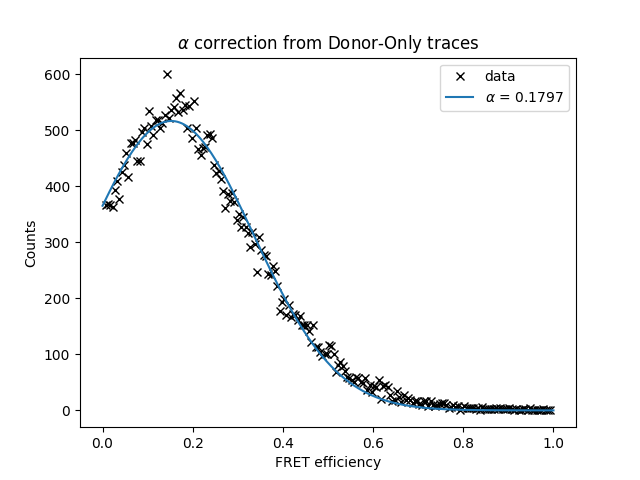

In [5]:
with open(file_path_DO[0]) as json_file:
    traces_dict_DO = load(json_file)
traces_dict_DO = calculate_FRET_Eff(traces_dict_DO)
alpha = calculate_alpha_corr_factor(traces_dict_DO)
print('alpha = ' + str(np.round(alpha, 4)))

*NB: In case you are not satisfied with the fit of the peak or it failed, you can manually fill the coordinates of the peak below, and calculate the related alpha factor. Otherwise, if the fit is OK, then skip the next cell.*

In [6]:
# example: x_c = [0.15]

x_c = []  # COMPLETE THIS

# calculation of the alpha correction factor; this is skipped if x_c is empty

if len(x_c)>0:
    alpha = x_c[0] / (1 - x_c[0])

## Calculation of the $\delta$ correction factor

Similarly to the $\alpha$ correction factor, the $\delta$ correction factor is is extracted from a normal fit of the FRET stoichiometry histogram of the Acceptor-Only dataset. $\delta$ is calculated according to the following: $\delta = y_c / (1-y_c)$, with $y_c$ the center of the fitted gaussian.

delta = 0.0586


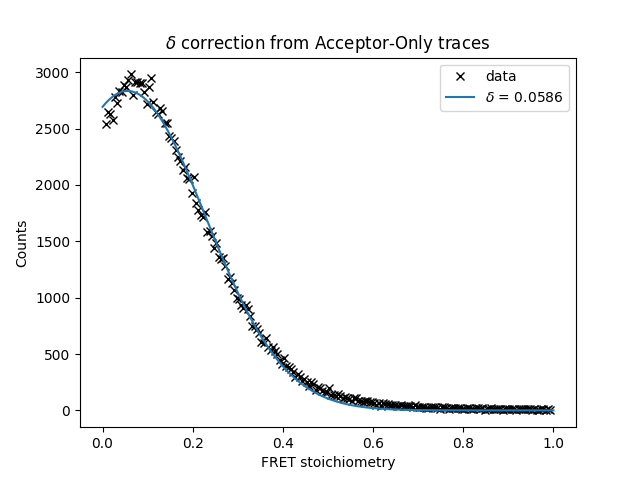

In [7]:
with open(file_path_AO[0]) as json_file:
    traces_dict_AO = load(json_file)
traces_dict_AO = calculate_FRET_Eff(traces_dict_AO)
delta = calculate_delta_corr_factor(traces_dict_AO)
print('delta = ' + str(np.round(delta, 4)))

*NB: In case you are not satisfied with the fit of the peak or it failed, you can manually fill the coordinates of the peak below, and calculate the related delta factor. Otherwise, if the fit is OK, then skip the next cell.*

In [8]:
# example: y_c = [0.12]

y_c = []  # COMPLETE THIS

# calculation of the delta correction factor; this is skipped if y_c is empty

if len(y_c)>0:
    delta = y_c[0] / (1 - y_c[0])

## Calculation of the $\beta$ and $\gamma$ correction factors

The $\beta$ and $\gamma$ correction factors are calculated from the FRET 2D histogram of the Donor-Acceptor dataset with previous $\alpha$-$\delta$ correction. The calculations are processed using the following steps:
1. calculation of the stoichiometry vs. efficiency FRET 2D histogram using the $\alpha$ and $\delta$ corrections
2. fit of the 2D peaks by 2D gaussian spots
3. extraction of the coordinates of the center of each 2D gaussian spots
4. linear fit of the inverse stiochiometry vs FRET efficiency using the coordinates of the peaks, such as: $Stoichio^{-1}=b\times Eff+a$
5. calculation of $\beta$ and $\gamma$, such as: $\beta = a+b-1$ and $\gamma = \frac{a-1}{a+b-1}$

An $\alpha$-$\delta$ corrected histogram is displayed with the fitted gaussian centers as red dots, so you can visually check that the fits are OK; otherwise try to change the number of FRET states, or manually add the coordinates of the peaks (see below).

C:\Users\molcre0000\Documents\PySMACKS_dev\scripts\utils.py:511: RuntimeWarning: invalid value encountered in divide
  traces_dict[i]['FRET_eff_corr'] = (trace_DA - alpha * trace_DD - delta * trace_AA) / (gamma * trace_DD + trace_DA - alpha * trace_DD - delta * trace_AA)
C:\Users\molcre0000\Documents\PySMACKS_dev\scripts\utils.py:513: RuntimeWarning: invalid value encountered in divide
  traces_dict[i]['FRET_stoi_corr'] = (trace_DA - alpha * trace_DD + gamma * trace_DD - delta * trace_AA) / (gamma * trace_DD + trace_DA - alpha * trace_DD + trace_AA / beta - delta * trace_AA)
C:\Users\molcre0000\Documents\PySMACKS_dev\scripts\utils.py:568: RuntimeWarning: invalid value encountered in cast
  hist2D_map[FRET_hist_bin[0][i].astype(int), FRET_hist_bin[1][i].astype(int)] += 1


beta = 1.0374
gamma = 0.8121


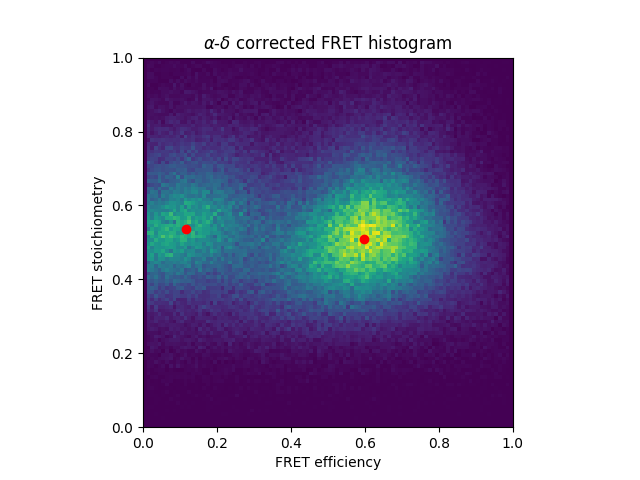

In [9]:
with open(file_path_DA[0]) as json_file:
    traces_dict_DA = load(json_file)
traces_dict_DA = calculate_FRET_Eff(traces_dict_DA)
traces_dict_DA = plot_corr_histo_FRET(traces_dict_DA, alpha, delta, 1, 1, plot_hist = 0, return_dict = 1, nb_bins = nb_bins)
beta, gamma = calculate_beta_gamma_corr_factor(traces_dict_DA, nb_gauss = nb_states, nb_bins = nb_bins)
print('beta = ' + str(np.round(beta,4)))
print('gamma = ' + str(np.round(gamma,4)))

*NB: In case you are not satisfied with the fit of the peaks or it failed, you can manually fill the coordinates of the peaks below, and calculate the related beta and gamma factors. Otherwise, if the fit is OK, then skip the next cell.*

*If you select manually the peaks, make sure you select them on the $\alpha$-$\delta$ corrected FRET histogram.*

In [10]:
# example: peak_fret_eff = [0.3, 0.7]
#          peak_fret_stoich = [0.51, 0.55]

peak_fret_eff = []  # COMPLETE THIS
peak_fret_stoich = []  # COMPLETE THIS

# linear fit of the inverse stoichiometry vs. fret efficiency; this is skipped if you didn't fill the peak_ variables

if len(peak_fret_eff)>0:
    b, a = np.polyfit(np.array(peak_fret_eff), 1/np.array(peak_fret_stoich), 1)

    beta = a + b -1
    gamma = (a - 1) / (a + b - 1)

## Extraction of the corrected FRET efficiency histogram

Plot the fully corrected ($\alpha$-$\delta$-$\beta$-$\gamma$) FRET stoichiometry vs. efficiency 2D histogram

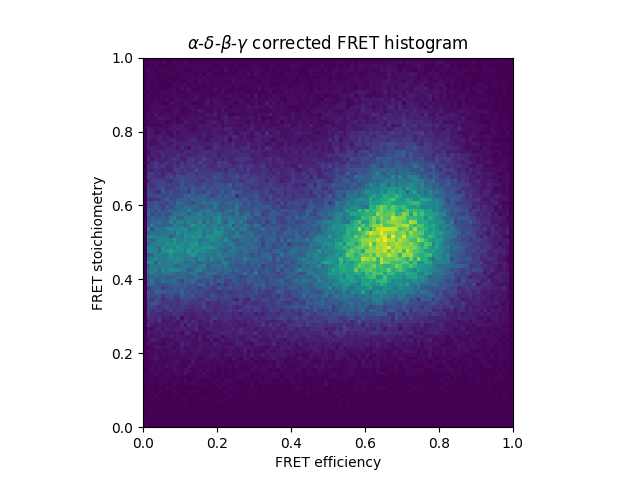

In [11]:
corr_histo = plot_corr_histo_FRET(traces_dict_DA, alpha, delta, beta, gamma, nb_bins = nb_bins)

From the corrected 2D histogram, extract the corrected FRET efficiency histogram and fit it using a mixed gaussian model (the number of individual gaussian is defined by the number of FRET states you defined at the beginning).

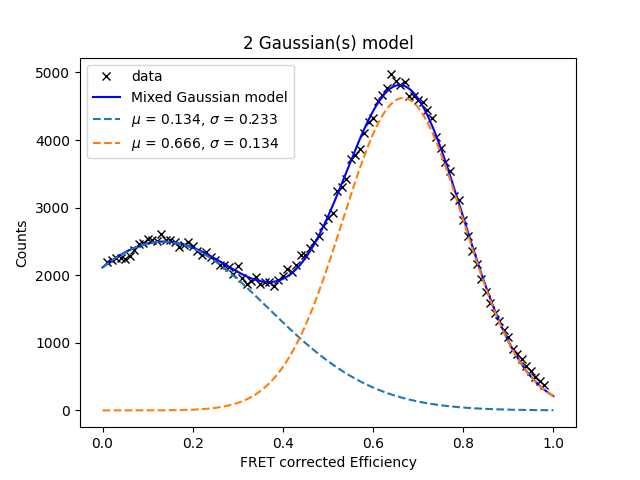

In [12]:
corr_FRET_eff_hist = np.sum(corr_histo, axis = 0)[1:-1]
    
x_fret_eff = np.linspace(1/nb_bins, (nb_bins - 2)/nb_bins, nb_bins-2)
    
hist_1D = np.stack((x_fret_eff, corr_FRET_eff_hist), axis = 0)
    
df_FRET_peaks = multi_fit_Gauss_spot(hist_1D, nb_gauss = nb_states)

Display the parameters of the fitted individual gaussians: Peak amplitude, mean FRET efficiency, standard deviation FRET effiency

In [13]:
print(df_FRET_peaks)

   FRET_peak_amplitude  FRET_peak_position  FRET_peak_STD
0          2496.206202            0.134108       0.233111
1          4621.967971            0.666377       0.134147
